# A. Importation of libraries and Configs

In [1]:
# Standard libraries
import pandas as pd

In [2]:
import os
from pathlib import Path

# Run once at the top — sets cwd to Thesis/
os.chdir(Path().resolve().parents[1])  # eda → notebooks → Thesis

In [3]:
from src.utils.data_loaders.read_settings_json import read_settings_json

args = read_settings_json()
args

{'Config': {'debug_mode': 'False', 'TEMP_CACHE': 'data/temp_cache'},
 'TrainingInput': {'CHART_OF_ACCOUNTS': 'data/training_input/chart_of_accounts.xlsx',
  'ENROLLEES': 'data/training_input/enrollees_pseudonymized.xlsx',
  'REVENUES': 'data/training_input/revenues_pseudonymized.xlsx'},
 'Training': {'MODEL_PARAMETERS': 'src/modules/machine_learning/parameters.json',
  'RESULTS_ROOT': 'data/training_results',
  'LOGS': 'data/training_logs',
  'DEPLOYED_MODELS': 'data/training_results/deployed_models',
  'observation_end': '2026/04/24',
  'target_feature': 'dtp_bracket',
  'test_size': '0.30'}}

# B. Loading of datasets

## 1. Revenues

In [4]:
df_revenues = pd.read_excel(args['TrainingInput']['REVENUES'], engine='calamine')

In [5]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
53437,54692,2026-04-22,2026-07-11,2026,K13NY2L3,G06-A-UE,NaN,31000.0,31000.0,Cash,0.0
53438,54693,2026-04-22,2026-07-11,2026,K13NY2L3,Discount - 2nd Sibling,G06-OF-Full,-700.0,0.0,Not Applicable,-700.0
53439,54694,2026-04-22,2026-07-11,2026,K13NY2L3,G06-OF-Full,NaN,17900.0,0.0,Not Applicable,17900.0
53440,54695,2026-04-24,2026-07-11,2026,XKJ70D79,Kn2-A-UE,NaN,26400.0,26400.0,Bank,0.0


## 2. Enrollees

In [6]:
df_enrollees = pd.read_excel(args['TrainingInput']['ENROLLEES'], engine='calamine')

In [7]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2780,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2781,2026,ZDC3I53X,Plan - B,G10,2026-03-30,Junior High,No Refund
2782,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund
2783,2026,ZQB34VX6,Plan - A,SpE,2026-01-20,Special Education,No Refund


## 3. Credit Sales

In [8]:
from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records:   10580
Multiple due date records: 289


In [9]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score
2257,2022,02PNVPI5,Kn2-C-1st,2800.0,0.0,0.0,2800.0,2022-09-09,2022-09-06,-3,...,9,3,0,1.034215,NaN,0,NaN,<NA>,<NA>,0
2412,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,1267,...,11,4,1,0.943797,1.0,1,0.0,<NA>,-3,0
2774,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,1237,...,12,4,1,0.881408,NaN,0,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Events - Foundation Day,490.0,0.0,0.0,490.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,0.0,0.0,2600.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9792,2025,ZXPL0CI9,G06-C-4th,5800.0,0.0,0.0,5800.0,2026-02-06,2026-02-09,3,...,2,1,1,0.972245,0.0,0,2.0,10.456258,34,0
9869,2025,ZXPL0CI9,Graduation - Other Services,1500.0,0.0,0.0,1500.0,2026-02-18,2026-03-23,33,...,2,1,1,0.992873,0.0,0,1.0,14.614491,34,0
9942,2025,ZXPL0CI9,Events - Foundation Day,400.0,0.0,0.0,400.0,2026-03-05,2026-03-11,6,...,3,1,1,0.990990,0.0,0,2.0,15.340578,34,0
9967,2025,ZXPL0CI9,G06-OF-3rd,5800.0,0.0,0.0,5800.0,2026-03-06,2026-03-11,5,...,3,1,1,0.964462,0.0,0,1.0,16.792856,34,0


# C. Exploratory Data Analysis

In [10]:
# Get counts
counts = df_credit_sales.dtp_bracket.value_counts()

# Convert to percentages
percentages = counts / counts.sum() * 100

# Combine into one DataFrame
result = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

print(result)

             count  percentage
dtp_bracket                   
on_time       3891       39.45
30_days       2998       30.40
90_days       1892       19.18
60_days       1081       10.96


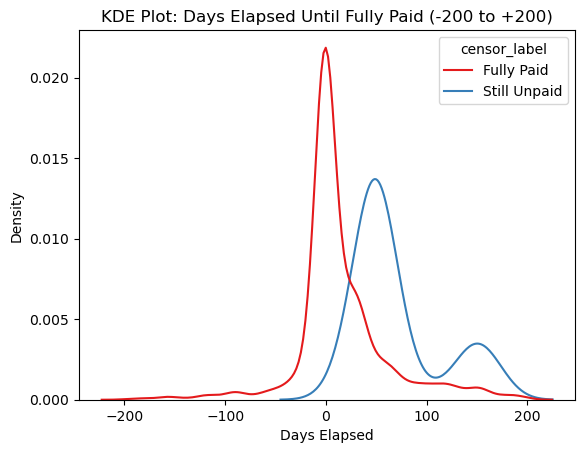

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Remove those that have no full dtp_history:
df_filtered = df_credit_sales.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])


# Clean and filter directly on the DataFrame
df_filtered = df_filtered.loc[
    df_filtered['days_elapsed_until_fully_paid']
        .replace("", np.nan)   # replace empty strings with NaN
        .dropna()              # drop NaNs
        .index                 # keep aligned index
]


# Apply numeric filter
df_filtered = df_filtered[
    (df_filtered['days_elapsed_until_fully_paid'] >= -200) &
    (df_filtered['days_elapsed_until_fully_paid'] <= 200)
]

# Convert censor column to categorical with labels
df_filtered["censor_label"] = (
    df_filtered["censor"]
    .map({0: "Still Unpaid", 1: "Fully Paid"})
    .astype("category")   # force categorical type
)


# KDE plot with grouping by categorical censor labels
sns.kdeplot(
    data=df_filtered,
    x="days_elapsed_until_fully_paid",
    hue="censor_label",
    fill=False,
    common_norm=False,
    palette="Set1"
)

plt.title("KDE Plot: Days Elapsed Until Fully Paid (-200 to +200)")
plt.xlabel("Days Elapsed")
plt.ylabel("Density")
plt.show()

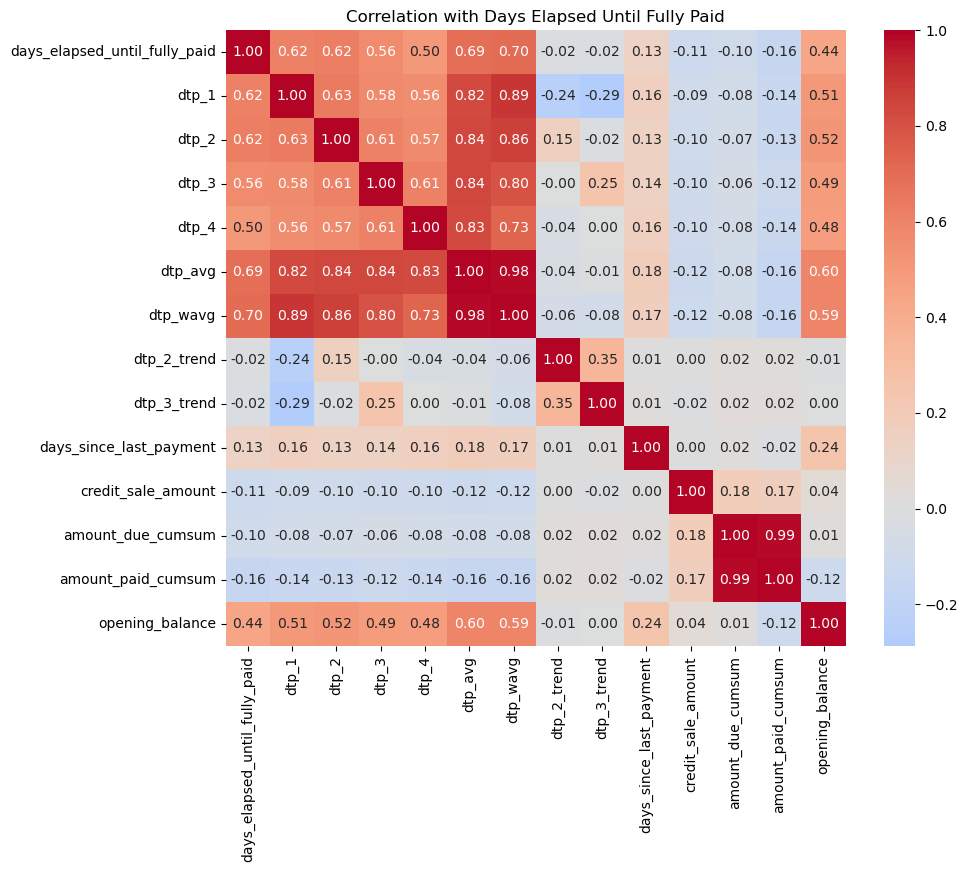

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid',
        'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
        'dtp_avg', 'dtp_wavg', 'dtp_2_trend',
        'dtp_3_trend', 'days_since_last_payment',
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

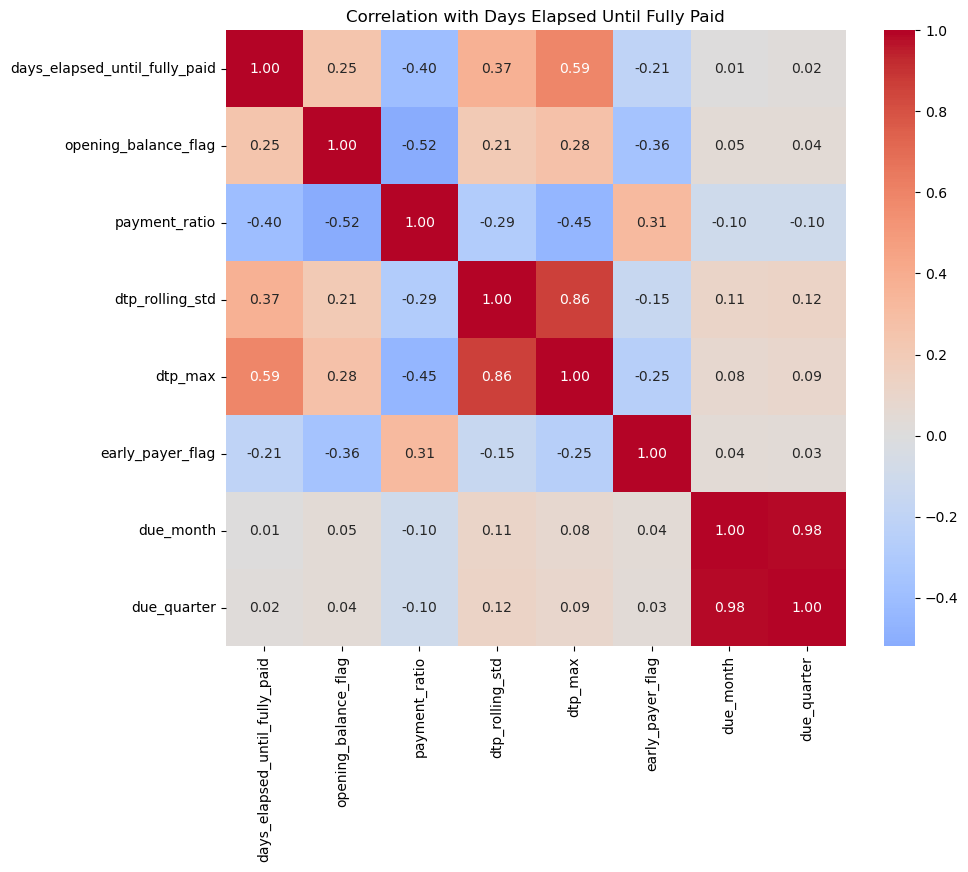

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 'opening_balance_flag', 'payment_ratio',
        'dtp_rolling_std', 'dtp_max', 'early_payer_flag',
        'due_month', 'due_quarter']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

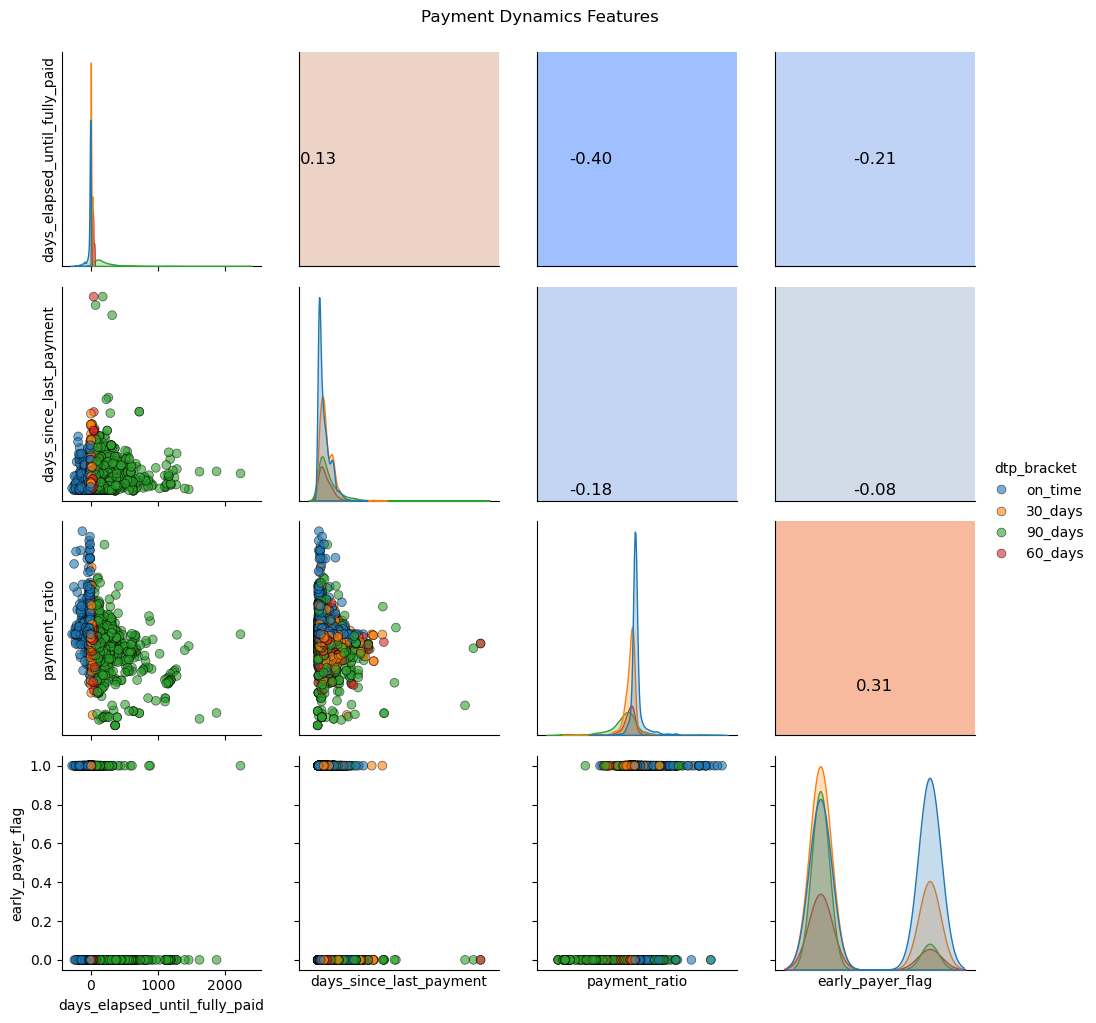

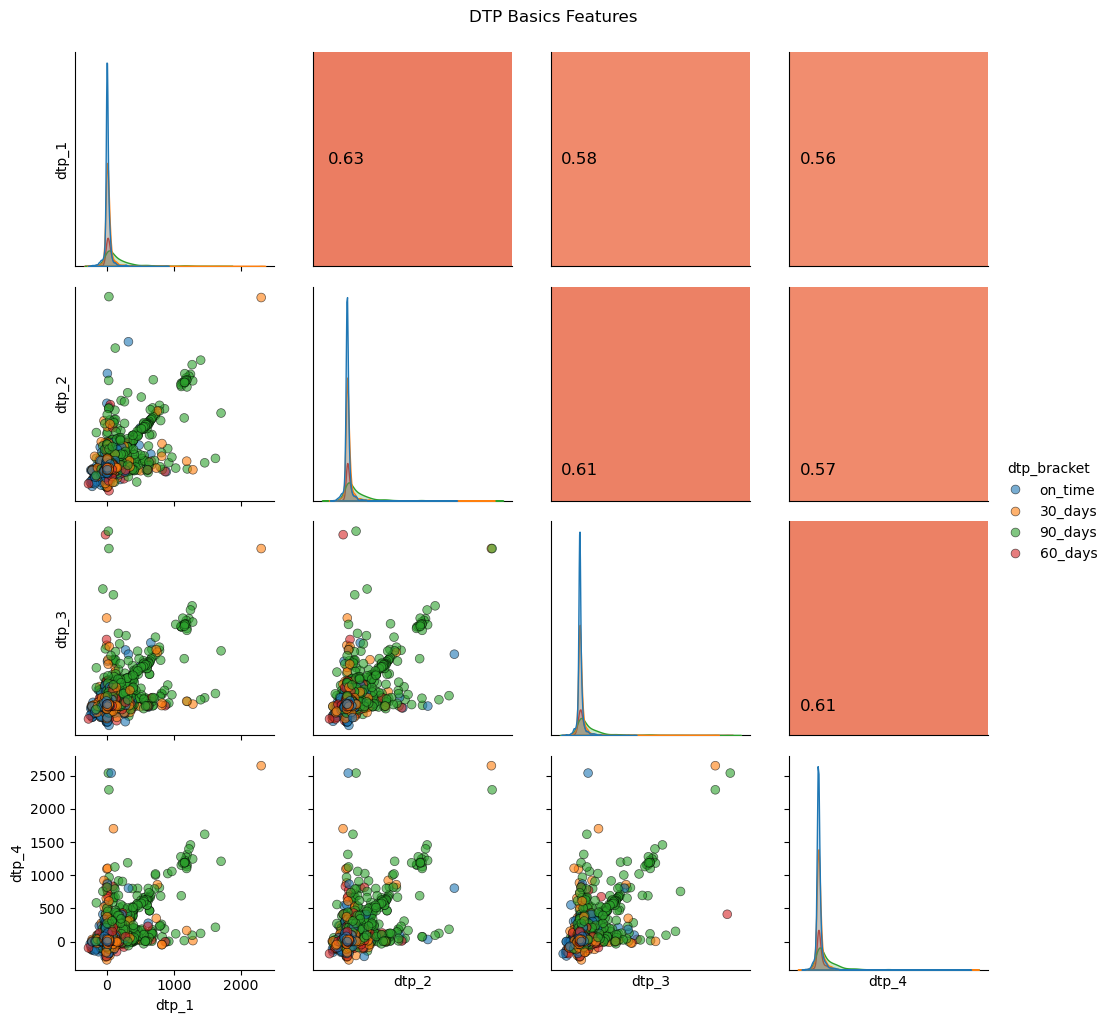

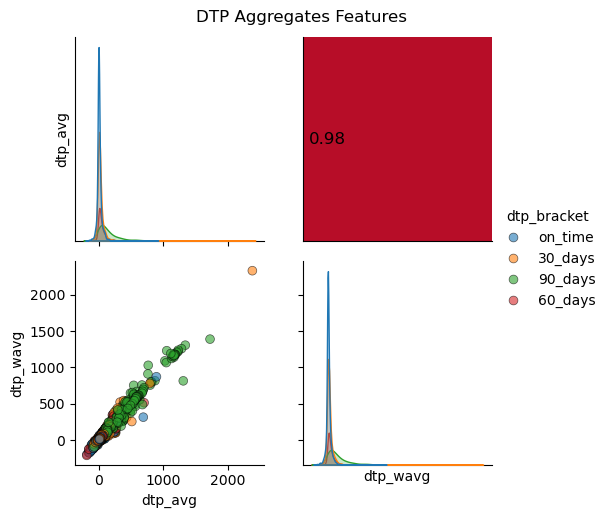

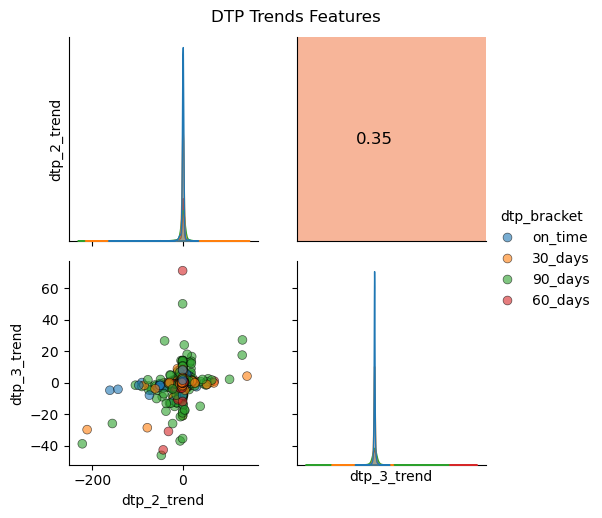

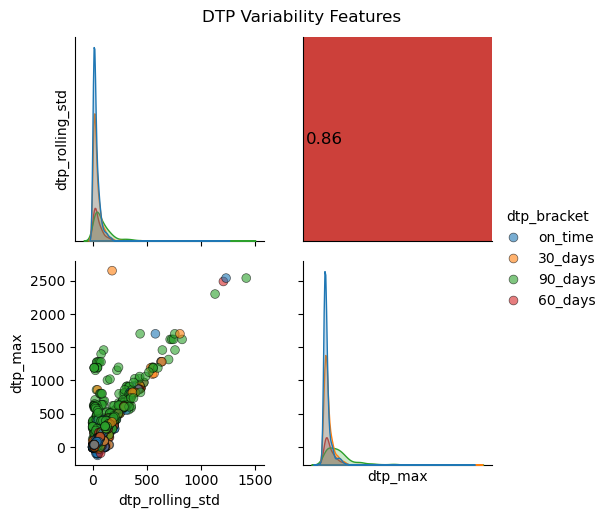

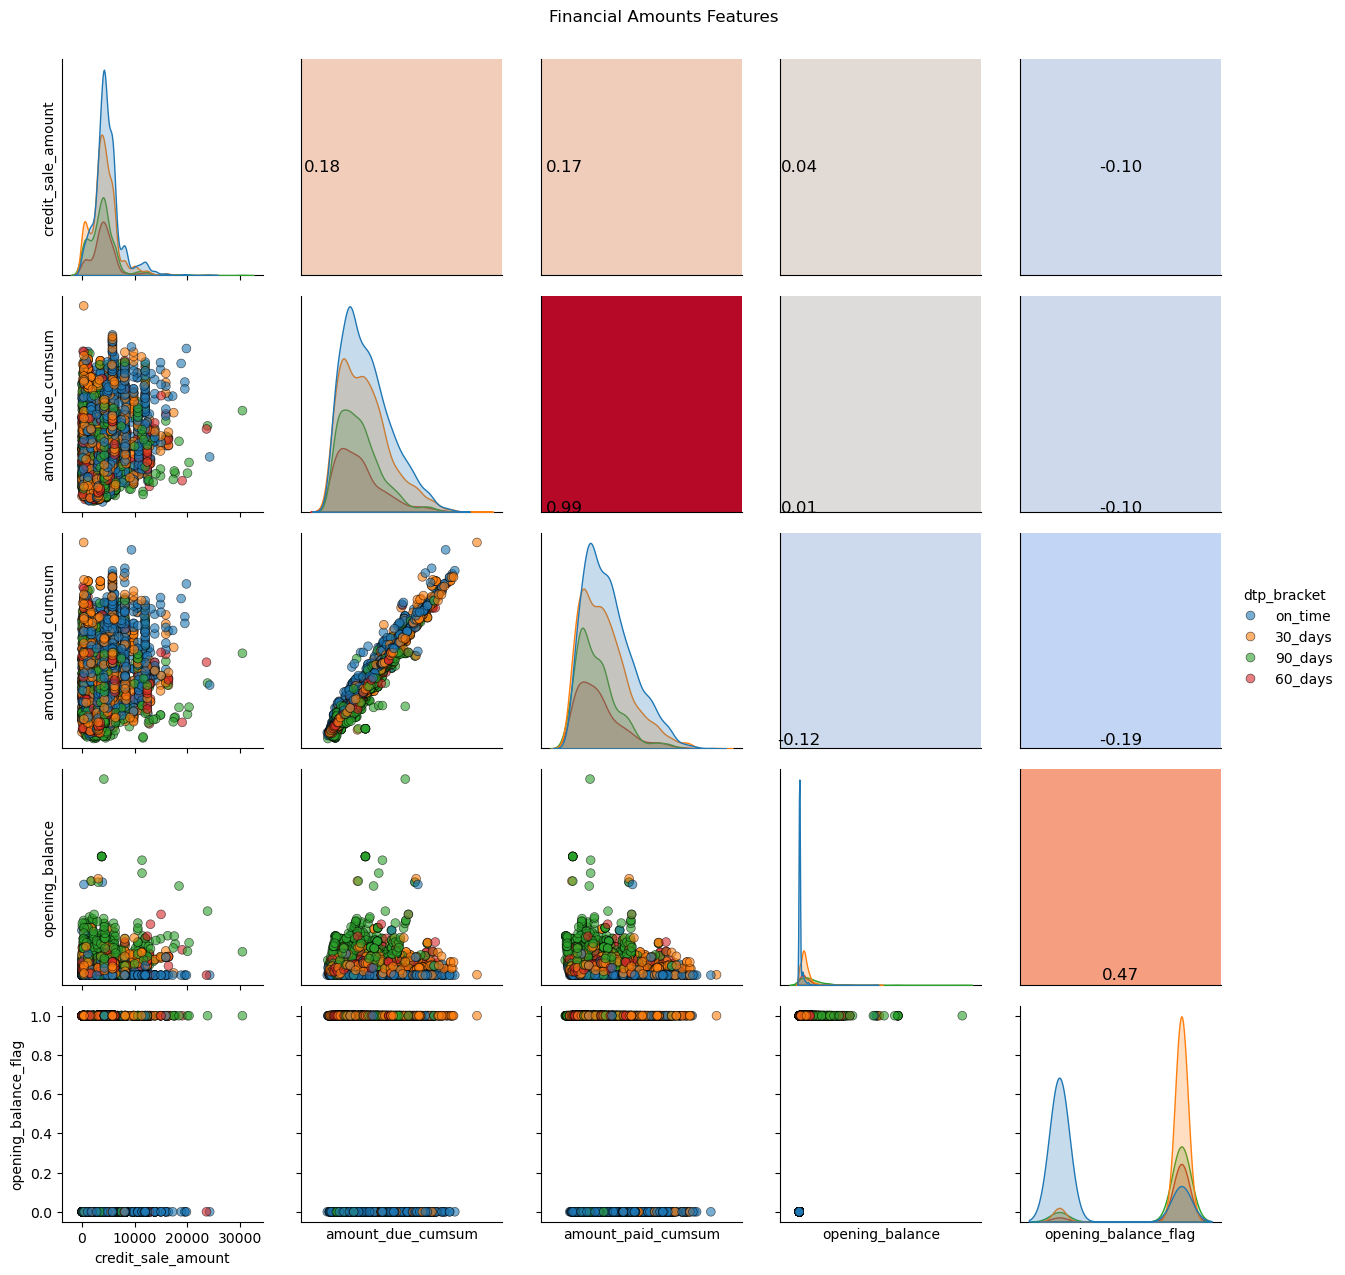

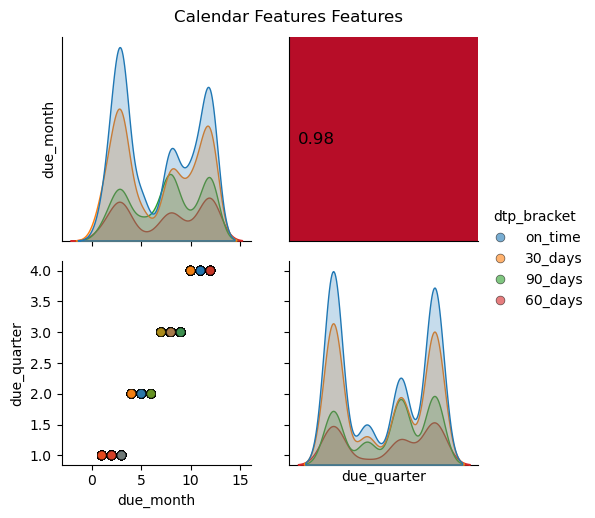

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter and clean data
df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Define groups of columns
groups = {
    "Payment Dynamics": [
        'days_elapsed_until_fully_paid', 'days_since_last_payment',
        'payment_ratio', 'early_payer_flag'
    ],
    "DTP Basics": ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'],
    "DTP Aggregates": ['dtp_avg', 'dtp_wavg'],
    "DTP Trends": ['dtp_2_trend', 'dtp_3_trend'],
    "DTP Variability": ['dtp_rolling_std', 'dtp_max'],
    "Financial Amounts": [
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance',
        'opening_balance_flag'
    ],
    "Calendar Features": ['due_month', 'due_quarter']
}

def pairgrid_with_heatmap(df, cols, hue, title):
    # Build grid
    g = sns.PairGrid(df[cols + [hue]], hue=hue, diag_sharey=False)

    # Lower triangle: scatterplots
    g.map_lower(sns.scatterplot, alpha=0.6, s=40, edgecolor='k')

    # Diagonal: KDE plots
    g.map_diag(sns.kdeplot, fill=True)

    # Upper triangle: correlation heatmap
    corr = df[cols].corr()
    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if j > i:  # upper triangle only
                ax = g.axes[i, j]
                c = corr.loc[col_i, col_j]
                # Map correlation [-1,1] to colormap
                ax.set_facecolor(plt.colormaps['coolwarm']((c+1)/2))
                ax.text(0.5, 0.5, f"{c:.2f}", ha='center', va='center', fontsize=12)
                ax.set_xticks([])
                ax.set_yticks([])

    g.add_legend()
    plt.suptitle(title, y=1.02)
    plt.show()

# Generate plots for each group
for group_name, cols in groups.items():
    pairgrid_with_heatmap(df_filtered, cols, 'dtp_bracket', f"{group_name} Features")